DATASET SHAPE
(49287, 9)

FIRST 5 ROWS
         date home_team away_team  home_score  away_score tournament     city  \
0  1872-11-30  Scotland   England         0.0         0.0   Friendly  Glasgow   
1  1873-03-08   England  Scotland         4.0         2.0   Friendly   London   
2  1874-03-07  Scotland   England         2.0         1.0   Friendly  Glasgow   
3  1875-03-06   England  Scotland         2.0         2.0   Friendly   London   
4  1876-03-04  Scotland   England         3.0         0.0   Friendly  Glasgow   

    country  neutral  
0  Scotland    False  
1   England    False  
2  Scotland    False  
3   England    False  
4  Scotland    False  

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49287 non-null  object 
 1   home_team   49287 non-null  object 
 2   away_team   49287 non-null  object 
 3   home

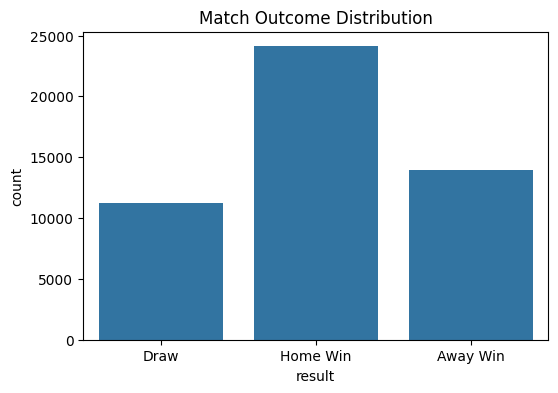

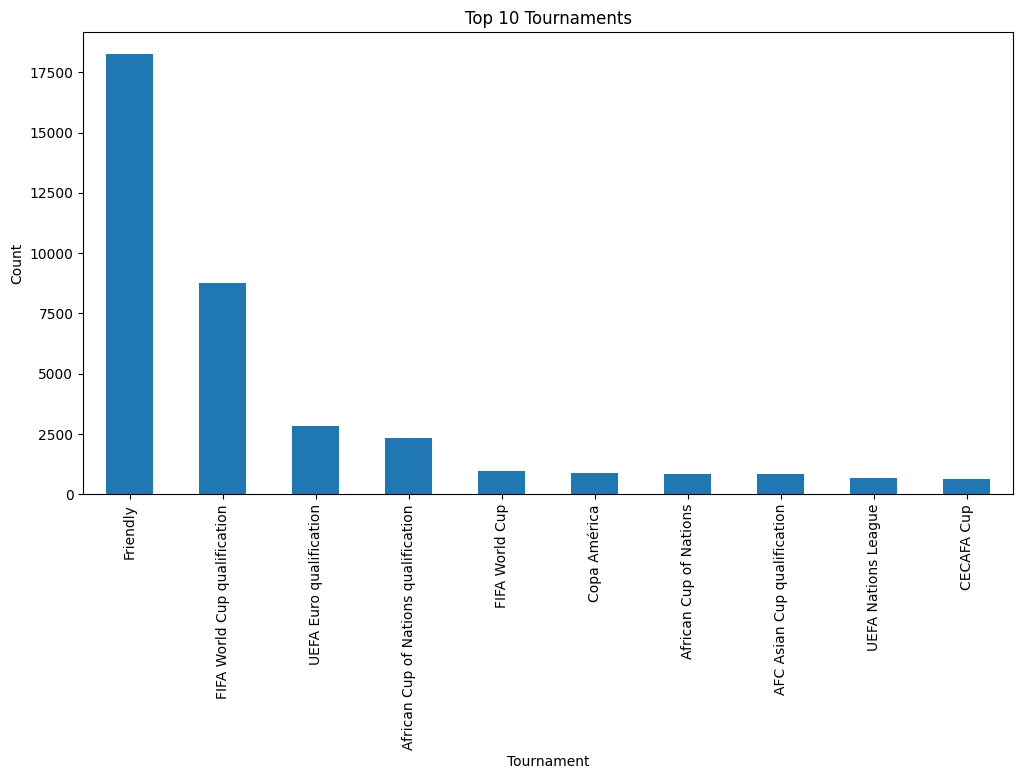

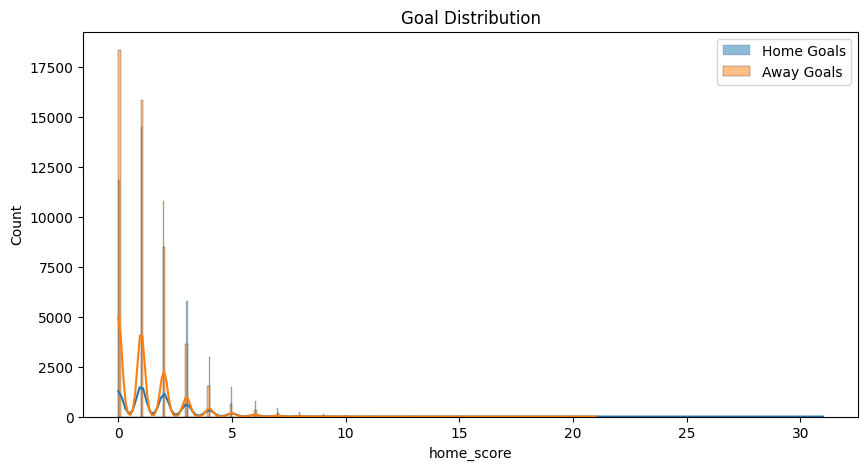

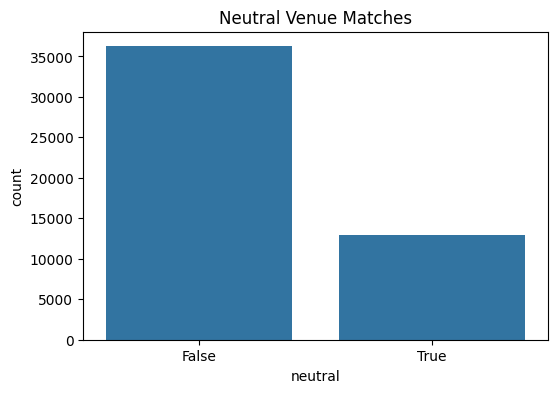


TRAIN TEST SPLIT
X_train: (39372, 6)
X_test: (9843, 6)

MODEL TRAINING + COMPARISON

Logistic Regression
Accuracy: 0.5803108808290155

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.54      0.54      0.54      2834
        Draw       0.32      0.07      0.12      2210
    Home Win       0.62      0.84      0.71      4799

    accuracy                           0.58      9843
   macro avg       0.49      0.48      0.46      9843
weighted avg       0.53      0.58      0.53      9843


Random Forest
Accuracy: 0.5173219546886112

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.49      0.44      0.47      2834
        Draw       0.28      0.20      0.23      2210
    Home Win       0.59      0.71      0.65      4799

    accuracy                           0.52      9843
   macro avg       0.46      0.45      0.45      9843
weighted avg       0.49      0.52      0.50      9843


Decision T

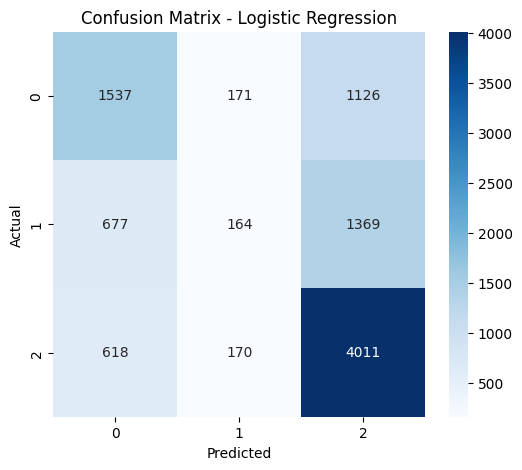


MODEL SAVED SUCCESSFULLY
Saved as: best_fifa_model.pkl

EDA + PIPELINE + AUTOMATED MODEL
COMPARISON COMPLETED SUCCESSFULLY!


In [2]:
# =========================================================
# FIFA MATCH OUTCOME PREDICTION — EDA + PIPELINE + AUTOML
# =========================================================

# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# =========================================================
# LOAD DATASET
# =========================================================

df = pd.read_csv("results.csv")

print("===================================")
print("DATASET SHAPE")
print("===================================")

print(df.shape)

print("\n===================================")
print("FIRST 5 ROWS")
print("===================================")

print(df.head())

print("\n===================================")
print("DATASET INFO")
print("===================================")

print(df.info())

# =========================================================
# MISSING VALUES
# =========================================================

print("\n===================================")
print("MISSING VALUES")
print("===================================")

print(df.isnull().sum())

# Drop rows with missing scores

df = df.dropna(subset=['home_score', 'away_score'])

# =========================================================
# CREATE TARGET VARIABLE
# =========================================================

def get_result(row):

    if row['home_score'] > row['away_score']:
        return 'Home Win'

    elif row['home_score'] < row['away_score']:
        return 'Away Win'

    else:
        return 'Draw'

df['result'] = df.apply(get_result, axis=1)

print("\n===================================")
print("TARGET VARIABLE DISTRIBUTION")
print("===================================")

print(df['result'].value_counts())

# =========================================================
# DATE FEATURE ENGINEERING
# =========================================================

df['date'] = pd.to_datetime(
    df['date'],
    format='mixed'
)

df['year'] = df['date'].dt.year

# =========================================================
# EDA VISUALIZATIONS
# =========================================================

# -----------------------------------
# Match Outcome Distribution
# -----------------------------------

plt.figure(figsize=(6,4))

sns.countplot(
    x='result',
    data=df
)

plt.title('Match Outcome Distribution')

plt.show()

# -----------------------------------
# Top Tournaments
# -----------------------------------

plt.figure(figsize=(12,6))

df['tournament'].value_counts().head(10).plot(
    kind='bar'
)

plt.title('Top 10 Tournaments')

plt.xlabel('Tournament')

plt.ylabel('Count')

plt.show()

# -----------------------------------
# Goal Distribution
# -----------------------------------

plt.figure(figsize=(10,5))

sns.histplot(
    df['home_score'],
    kde=True,
    label='Home Goals'
)

sns.histplot(
    df['away_score'],
    kde=True,
    label='Away Goals'
)

plt.legend()

plt.title('Goal Distribution')

plt.show()

# -----------------------------------
# Neutral Venue Analysis
# -----------------------------------

plt.figure(figsize=(6,4))

sns.countplot(
    x='neutral',
    data=df
)

plt.title('Neutral Venue Matches')

plt.show()

# =========================================================
# FEATURES + TARGET
# =========================================================

X = df[[
    'home_team',
    'away_team',
    'tournament',
    'country',
    'neutral',
    'year'
]]

y = df['result']

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\n===================================")
print("TRAIN TEST SPLIT")
print("===================================")

print("X_train:", X_train.shape)

print("X_test:", X_test.shape)

# =========================================================
# PREPROCESSING PIPELINE
# =========================================================

categorical_features = [
    'home_team',
    'away_team',
    'tournament',
    'country'
]

numeric_features = [
    'year'
]

boolean_features = [
    'neutral'
]

# -----------------------------------
# Categorical Pipeline
# -----------------------------------

categorical_pipeline = Pipeline([

    (
        'imputer',
        SimpleImputer(
            strategy='most_frequent'
        )
    ),

    (
        'encoder',
        OneHotEncoder(
            handle_unknown='ignore'
        )
    )
])

# -----------------------------------
# Numeric Pipeline
# -----------------------------------

numeric_pipeline = Pipeline([

    (
        'imputer',
        SimpleImputer(
            strategy='median'
        )
    ),

    (
        'scaler',
        StandardScaler()
    )
])

# -----------------------------------
# Full Preprocessor
# -----------------------------------

preprocessor = ColumnTransformer([

    (
        'categorical',
        categorical_pipeline,
        categorical_features
    ),

    (
        'numeric',
        numeric_pipeline,
        numeric_features
    ),

    (
        'boolean',
        'passthrough',
        boolean_features
    )
])

# =========================================================
# AUTOMATED MODEL COMPARISON
# =========================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        )
}

best_accuracy = 0

best_model_name = ""

best_pipeline = None

results = []

print("\n===================================")
print("MODEL TRAINING + COMPARISON")
print("===================================")

# =========================================================
# TRAIN + EVALUATE LOOP
# =========================================================

for name, model in models.items():

    # -----------------------------------
    # Full Pipeline
    # -----------------------------------

    pipeline = Pipeline([

        (
            'preprocessor',
            preprocessor
        ),

        (
            'model',
            model
        )
    ])

    # -----------------------------------
    # Train Model
    # -----------------------------------

    pipeline.fit(
        X_train,
        y_train
    )

    # -----------------------------------
    # Predictions
    # -----------------------------------

    preds = pipeline.predict(
        X_test
    )

    # -----------------------------------
    # Accuracy
    # -----------------------------------

    acc = accuracy_score(
        y_test,
        preds
    )

    results.append(
        [name, acc]
    )

    print(f"\n{name}")

    print(f"Accuracy: {acc}")

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            preds
        )
    )

    # -----------------------------------
    # Store Best Model
    # -----------------------------------

    if acc > best_accuracy:

        best_accuracy = acc

        best_model_name = name

        best_pipeline = pipeline

# =========================================================
# RESULTS TABLE
# =========================================================

results_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy']
)

print("\n===================================")
print("MODEL COMPARISON RESULTS")
print("===================================")

print(
    results_df.sort_values(
        by='Accuracy',
        ascending=False
    )
)

# =========================================================
# BEST MODEL
# =========================================================

print("\n===================================")
print("BEST MODEL")
print("===================================")

print("Best Model:", best_model_name)

print("Best Accuracy:", best_accuracy)

# =========================================================
# CONFUSION MATRIX
# =========================================================

best_preds = best_pipeline.predict(X_test)

cm = confusion_matrix(
    y_test,
    best_preds
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    f'Confusion Matrix - {best_model_name}'
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

# =========================================================
# SAVE BEST MODEL
# =========================================================

joblib.dump(
    best_pipeline,
    'best_fifa_model.pkl'
)

print("\n===================================")
print("MODEL SAVED SUCCESSFULLY")
print("===================================")

print("Saved as: best_fifa_model.pkl")

# =========================================================
# PIPELINE COMPLETE
# =========================================================

print("\n===================================")
print("EDA + PIPELINE + AUTOMATED MODEL")
print("COMPARISON COMPLETED SUCCESSFULLY!")
print("===================================")